# NLP Customer Review Analysis — DustiniaDelixia Groceria
**Persona:** Customer Experience Analyst  
**Tujuan:** Memahami *mengapa* pelanggan memberi ulasan rendah vs tinggi melalui analisis teks bahasa Portugis Brazil  
**Dataset:** `order_reviews.csv` — 99.224 ulasan, rentang waktu 2016–2018  

**Pipeline analisis:**
1. Setup & instalasi dependencies
2. Load & eksplorasi data
3. Preprocessing teks (bahasa Portugis Brazil)
4. TF-IDF per kelompok skor — keyword paling informatif
5. BERTopic — topic modeling tanpa supervised label
6. Sentiment analysis dengan model multilingual
7. Named entity & keyword extraction (low vs high)
8. Ringkasan insight bisnis & rekomendasi
9. Simpan semua visualisasi & hasil ke file

## 1. Setup & Instalasi

### 1.1 Install semua dependencies yang dibutuhkan

In [1]:
# # 1.1 — Install dependencies
# # BERTopic untuk topic modeling, sentence-transformers untuk embedding multilingual
# # NLTK & spaCy untuk preprocessing Portugis

# !pip install -q bertopic
# !pip install -q sentence-transformers
# !pip install -q transformers
# !pip install -q umap-learn hdbscan
# !pip install -q nltk
# !pip install -q wordcloud
# !pip install -q plotly
# !pip install -q pyLDAvis
# !pip install -q spacy
# !python -m spacy download pt_core_news_sm -q

# print("Instalasi selesai.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 35.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Instalasi selesai.


### 1.2 Import semua library

In [2]:
# 1.2 — Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import re
import os
import warnings
import json
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from wordcloud import WordCloud

# BERTopic
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)



True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Folder utama project di Google Drive
PROJECT_DIR = '/content/drive/MyDrive/FP_MCI_Lab'
DATASET_DIR = '/content/drive/MyDrive/FP_MCI_Data/Dataset'

# Folder output NLP
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'outputs', 'nlp')
PLOT_DIR = os.path.join(PROJECT_DIR, 'docs', 'assets', 'nlp')
TABLE_DIR = os.path.join(PROJECT_DIR, 'data', 'processed', 'nlp')

for d in [OUTPUT_DIR, PLOT_DIR, TABLE_DIR]:
    os.makedirs(d, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print(f"Project dir : {PROJECT_DIR}")
print(f"Dataset dir : {DATASET_DIR}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Plot dir    : {PLOT_DIR}")
print(f"Table dir   : {TABLE_DIR}")

Mounted at /content/drive
Project dir : /content/drive/MyDrive/FP_MCI_Lab
Dataset dir : /content/drive/MyDrive/FP_MCI_Data/Dataset
Output dir  : /content/drive/MyDrive/FP_MCI_Lab/outputs/nlp
Plot dir    : /content/drive/MyDrive/FP_MCI_Lab/docs/assets/nlp
Table dir   : /content/drive/MyDrive/FP_MCI_Lab/data/processed/nlp


## 2. Load & Eksplorasi Data

### 2.1 Load dataset dan preview awal

In [4]:
# 2.1 Load dataset
file_path = os.path.join(DATASET_DIR, 'order_reviews.csv')
df = pd.read_csv(file_path)

print(f"Shape dataset: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")

df.head()

Shape dataset: (99224, 7)
Kolom: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


### 2.2 Distribusi review score & cakupan teks

In [5]:
# 2.2 — Distribusi review score

score_dist = df['review_score'].value_counts().sort_index()
total = len(df)

print("Distribusi Review Score:")
for score, count in score_dist.items():
    bar = '█' * int(count / total * 50)
    print(f"  Score {score}: {count:>6} ({count/total*100:.1f}%)  {bar}")

print(f"\nTotal ulasan: {total:,}")
print(f"Rata-rata skor: {df['review_score'].mean():.3f}")
print(f"Skor 1-2 (Low):  {score_dist[1]+score_dist[2]:,} ({(score_dist[1]+score_dist[2])/total*100:.1f}%)")
print(f"Skor 4-5 (High): {score_dist[4]+score_dist[5]:,} ({(score_dist[4]+score_dist[5])/total*100:.1f}%)")

Distribusi Review Score:
  Score 1:  11424 (11.5%)  █████
  Score 2:   3151 (3.2%)  █
  Score 3:   8179 (8.2%)  ████
  Score 4:  19142 (19.3%)  █████████
  Score 5:  57328 (57.8%)  ████████████████████████████

Total ulasan: 99,224
Rata-rata skor: 4.086
Skor 1-2 (Low):  14,575 (14.7%)
Skor 4-5 (High): 76,470 (77.1%)


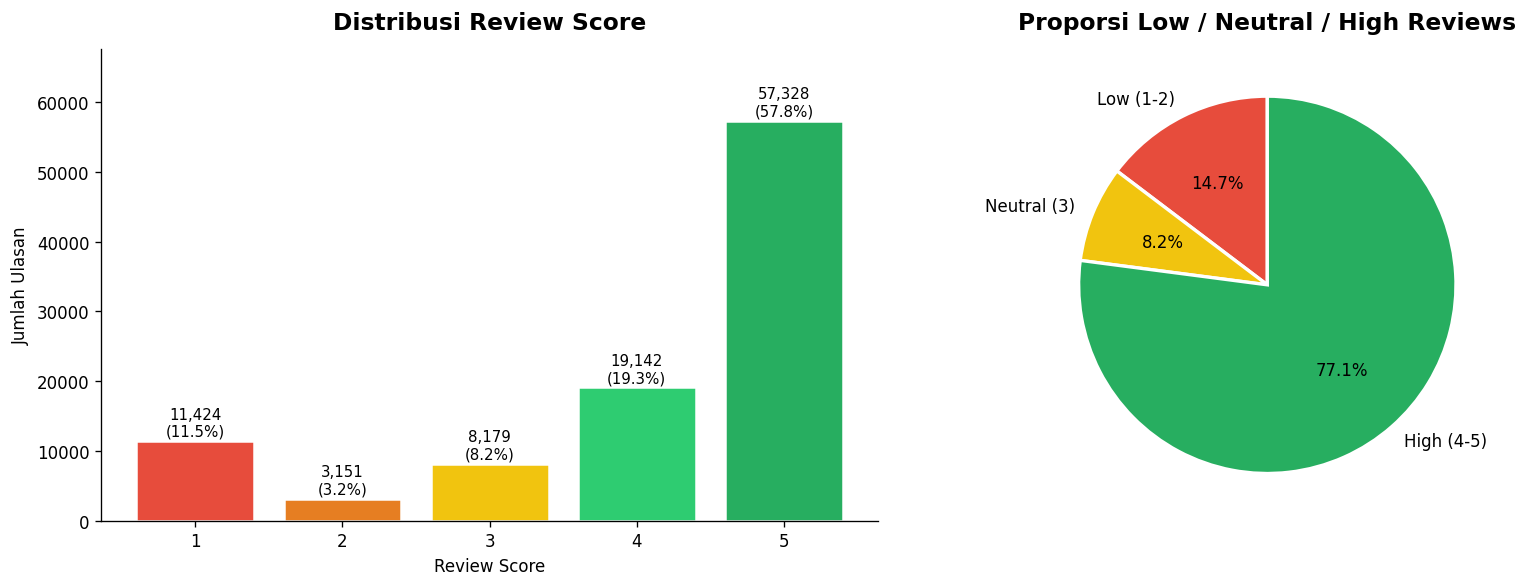

Tersimpan: 01_distribusi_review_score.png


In [6]:
# 2.2 lanjutan — Visualisasi distribusi skor

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

# Bar chart
bars = axes[0].bar(score_dist.index, score_dist.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Review Score', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Jumlah Ulasan')
for bar, count in zip(bars, score_dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'{count:,}\n({count/total*100:.1f}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0, score_dist.max() * 1.18)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart — Low / Neutral / High
groups = {
    'Low (1-2)': score_dist[1] + score_dist[2],
    'Neutral (3)': score_dist[3],
    'High (4-5)': score_dist[4] + score_dist[5],
}
axes[1].pie(
    groups.values(),
    labels=groups.keys(),
    colors=['#e74c3c', '#f1c40f', '#27ae60'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Low / Neutral / High Reviews', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_distribusi_review_score.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 01_distribusi_review_score.png")

In [7]:
# 2.2 lanjutan — Cakupan teks per skor
# Kolom review_comment_message = teks ulasan utama
# Kolom review_comment_title = judul singkat ulasan

print("Cakupan teks per score:")
print(f"{'Score':<8} {'Total':<10} {'Ada Teks':<12} {'Coverage %':<12}")
for score in [1,2,3,4,5]:
    sub = df[df['review_score'] == score]
    has_text = sub['review_comment_message'].notna().sum()
    pct = has_text / len(sub) * 100
    print(f"  {score:<6} {len(sub):<10,} {has_text:<12,} {pct:<12.1f}")

print("\nCatatan: Score 1 memiliki coverage teks tertinggi karena")
print("pelanggan yang kecewa cenderung lebih terdorong untuk menulis ulasan.")

Cakupan teks per score:
Score    Total      Ada Teks     Coverage %  
  1      11,424     8,745        76.5        
  2      3,151      2,145        68.1        
  3      8,179      3,557        43.5        
  4      19,142     5,976        31.2        
  5      57,328     20,554       35.9        

Catatan: Score 1 memiliki coverage teks tertinggi karena
pelanggan yang kecewa cenderung lebih terdorong untuk menulis ulasan.


### 2.3 Tren temporal ulasan

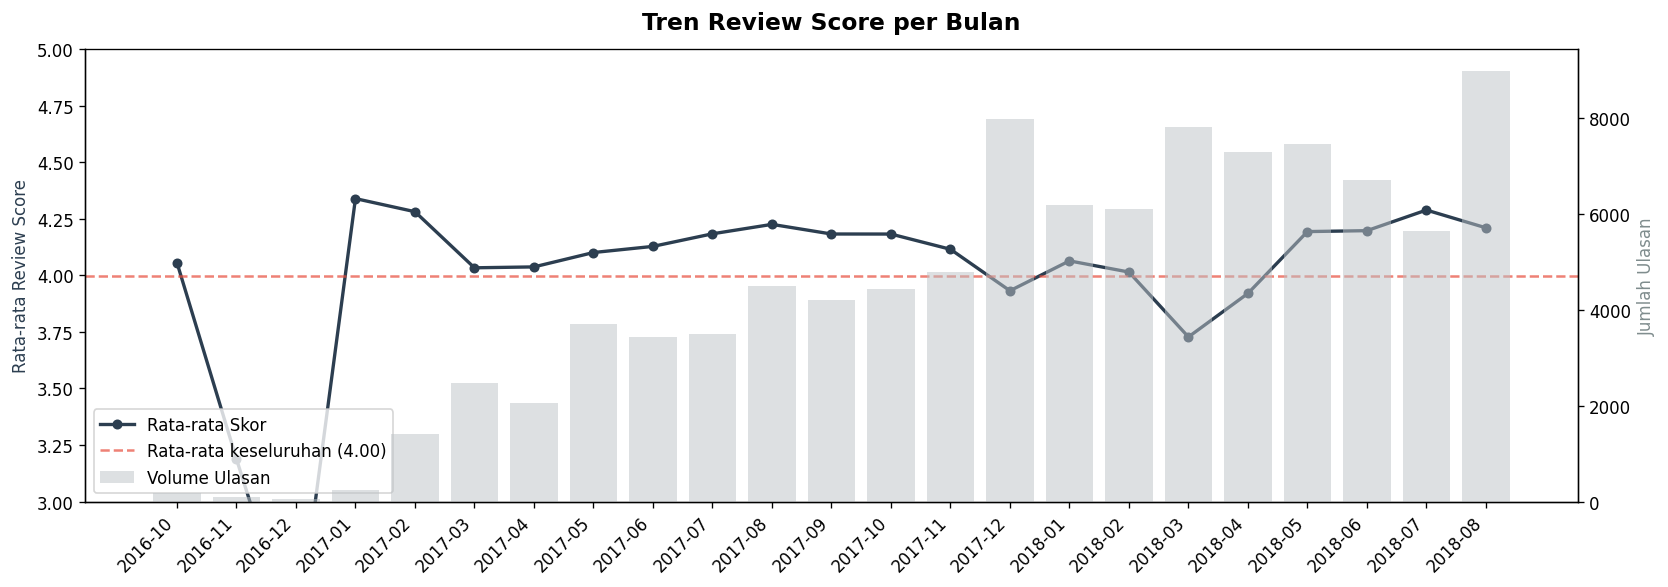

Tersimpan: 02_tren_score_bulanan.png


In [8]:
# 2.3 — Tren skor rata-rata per bulan

df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])
df['year_month'] = df['review_creation_date'].dt.to_period('M')

monthly = df.groupby('year_month').agg(
    avg_score=('review_score', 'mean'),
    count=('review_score', 'count'),
    low_pct=('review_score', lambda x: (x <= 2).mean() * 100)
).reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax2 = ax1.twinx()
ax2.bar(monthly['year_month_str'], monthly['count'], color='#bdc3c7', alpha=0.5, label='Volume Ulasan')
ax2.set_ylabel('Jumlah Ulasan', color='#7f8c8d')

ax1.plot(monthly['year_month_str'], monthly['avg_score'], color='#2c3e50', marker='o',
         markersize=5, linewidth=2, label='Rata-rata Skor')
ax1.axhline(y=monthly['avg_score'].mean(), color='#e74c3c', linestyle='--', alpha=0.7,
            label=f"Rata-rata keseluruhan ({monthly['avg_score'].mean():.2f})")
ax1.set_ylabel('Rata-rata Review Score', color='#2c3e50')
ax1.set_ylim(3.0, 5.0)
ax1.set_title('Tren Review Score per Bulan', fontsize=14, fontweight='bold', pad=12)

tick_step = max(1, len(monthly) // 12)
ax1.set_xticks(range(0, len(monthly), tick_step))
ax1.set_xticklabels(monthly['year_month_str'].iloc[::tick_step], rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

ax1.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_tren_score_bulanan.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 02_tren_score_bulanan.png")

## 3. Preprocessing Teks Bahasa Portugis Brazil

### 3.1 Definisi stopwords dan fungsi pembersih teks

In [9]:
# 3.1 — Stopwords Portugis Brazil + kata-kata tidak informatif untuk e-commerce

pt_stopwords = set(stopwords.words('portuguese'))

# Tambahan stopwords kontekstual e-commerce yang tidak memberi nilai analitik
custom_stopwords = {
    'produto', 'compra', 'loja', 'site', 'vendedor',
    'ótimo', 'bom', 'ruim', 'muito', 'mais',
    'tudo', 'nao', 'não', 'ser', 'pra', 'pois',
    'todo', 'toda', 'bem', 'super', 'um', 'uma',
    'ok', 'ja', 'ja', 'ate', 'esse', 'essa',
    'so', 'só', 'ta', 'tá', 'né', 'ai', 'aí',
    'gostei', 'recomendo', 'recomendo', 'boa',
    'recebi', 'chegou'
}
all_stopwords = pt_stopwords | custom_stopwords

def preprocess_text(text, min_token_len=3):
    """
    Membersihkan dan menormalisasi teks bahasa Portugis Brazil.
    - Lowercase
    - Hapus angka, URL, karakter khusus
    - Hapus stopwords
    - Filter token pendek
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-záàâãéèêíïóôõöúüçñ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in all_stopwords and len(t) >= min_token_len]
    return ' '.join(tokens)

print("Fungsi preprocessing siap.")
print(f"Total stopwords: {len(all_stopwords)}")
print()
# Test
sample = "Recebi bem antes do prazo estipulado, produto chegou em ótimas condições!"
print(f"Input:  {sample}")
print(f"Output: {preprocess_text(sample)}")

Fungsi preprocessing siap.
Total stopwords: 237

Input:  Recebi bem antes do prazo estipulado, produto chegou em ótimas condições!
Output: antes prazo estipulado ótimas condições


### 3.2 Buat dataframe teks terproses

In [10]:
# 3.2 — Gabungkan title + message, lalu preprocess
# Title memberikan sinyal singkat ("entrega perfeita", "não chegou")
# Message memberikan konteks detail

df['raw_text'] = (
    df['review_comment_title'].fillna('') + ' ' +
    df['review_comment_message'].fillna('')
).str.strip()

df['clean_text'] = df['raw_text'].apply(preprocess_text)

# Filter hanya baris yang memiliki teks bermakna (min 3 kata setelah preprocessing)
df_text = df[
    (df['clean_text'].str.len() > 5) &
    (df['clean_text'].str.split().str.len() >= 3)
].copy().reset_index(drop=True)

print(f"Total ulasan dengan teks: {len(df_text):,}")
print(f"Distribusi per score:")
print(df_text['review_score'].value_counts().sort_index())

# Label biner untuk analisis low vs high
df_text['sentiment_label'] = df_text['review_score'].apply(
    lambda x: 'LOW (1-2)' if x <= 2 else ('NEUTRAL (3)' if x == 3 else 'HIGH (4-5)')
)

df_text['is_low'] = df_text['review_score'] <= 2

print(f"\nLabel distribusi:")
print(df_text['sentiment_label'].value_counts())

Total ulasan dengan teks: 28,722
Distribusi per score:
review_score
1     7378
2     1852
3     2800
4     3864
5    12828
Name: count, dtype: int64

Label distribusi:
sentiment_label
HIGH (4-5)     16692
LOW (1-2)       9230
NEUTRAL (3)     2800
Name: count, dtype: int64


## 4. TF-IDF Analysis — Keyword Paling Informatif per Skor

### 4.1 Fit TF-IDF dan ekstrak top keywords per kelompok skor

In [11]:
# 4.1 — TF-IDF per kelompok: LOW (1-2) vs HIGH (4-5)
# Pendekatan: hitung TF-IDF untuk masing-masing grup, ambil term dengan skor tertinggi
# Ini mengungkap kata-kata yang UNIK dan PENTING untuk tiap kelompok skor

# Pisahkan corpus
corpus_low  = df_text[df_text['review_score'] <= 2]['clean_text'].tolist()
corpus_high = df_text[df_text['review_score'] >= 4]['clean_text'].tolist()
corpus_mid  = df_text[df_text['review_score'] == 3]['clean_text'].tolist()
corpus_all  = df_text['clean_text'].tolist()

print(f"Corpus LOW  (1-2): {len(corpus_low):,} dokumen")
print(f"Corpus MID  (3):   {len(corpus_mid):,} dokumen")
print(f"Corpus HIGH (4-5): {len(corpus_high):,} dokumen")

Corpus LOW  (1-2): 9,230 dokumen
Corpus MID  (3):   2,800 dokumen
Corpus HIGH (4-5): 16,692 dokumen


In [12]:
# 4.1 lanjutan — Fungsi ekstrak top TF-IDF terms dari suatu corpus

def get_top_tfidf_terms(corpus, n_top=30, ngram_range=(1, 2)):
    """
    Menghitung TF-IDF untuk corpus dan mengembalikan top N terms beserta skornya.
    Menggunakan unigram + bigram untuk menangkap frasa seperti 'entrega rapida'.
    """
    tfidf = TfidfVectorizer(
        ngram_range=ngram_range,
        min_df=5,
        max_df=0.85,
        sublinear_tf=True
    )
    tfidf_matrix = tfidf.fit_transform(corpus)

    # Rata-rata skor TF-IDF di seluruh dokumen untuk tiap term
    mean_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    terms = tfidf.get_feature_names_out()

    df_terms = pd.DataFrame({'term': terms, 'tfidf_score': mean_scores})
    return df_terms.sort_values('tfidf_score', ascending=False).head(n_top)

top_low  = get_top_tfidf_terms(corpus_low,  n_top=30)
top_high = get_top_tfidf_terms(corpus_high, n_top=30)
top_mid  = get_top_tfidf_terms(corpus_mid,  n_top=20)

print("Top keywords — LOW score (1-2):")
print(top_low.head(15).to_string(index=False))
print()
print("Top keywords — HIGH score (4-5):")
print(top_high.head(15).to_string(index=False))

Top keywords — LOW score (1-2):
     term  tfidf_score
  comprei     0.028187
     veio     0.026012
  entrega     0.025738
    ainda     0.023865
 entregue     0.023738
    prazo     0.017961
   pedido     0.015884
      dia     0.014389
    agora     0.013610
   apenas     0.011958
    quero     0.011424
     nada     0.011251
 produtos     0.011223
     dois     0.011157
qualidade     0.010683

Top keywords — HIGH score (4-5):
          term  tfidf_score
         prazo     0.058237
         antes     0.051473
   antes prazo     0.045807
       entrega     0.044332
      entregue     0.029893
     qualidade     0.025122
     excelente     0.022805
        rápida     0.019654
entregue antes     0.018522
entrega rápida     0.017666
        dentro     0.017617
  dentro prazo     0.015065
 entrega antes     0.015063
          veio     0.014549
         ótima     0.013876


### 4.2 Visualisasi TF-IDF — Horizontal bar chart per grup

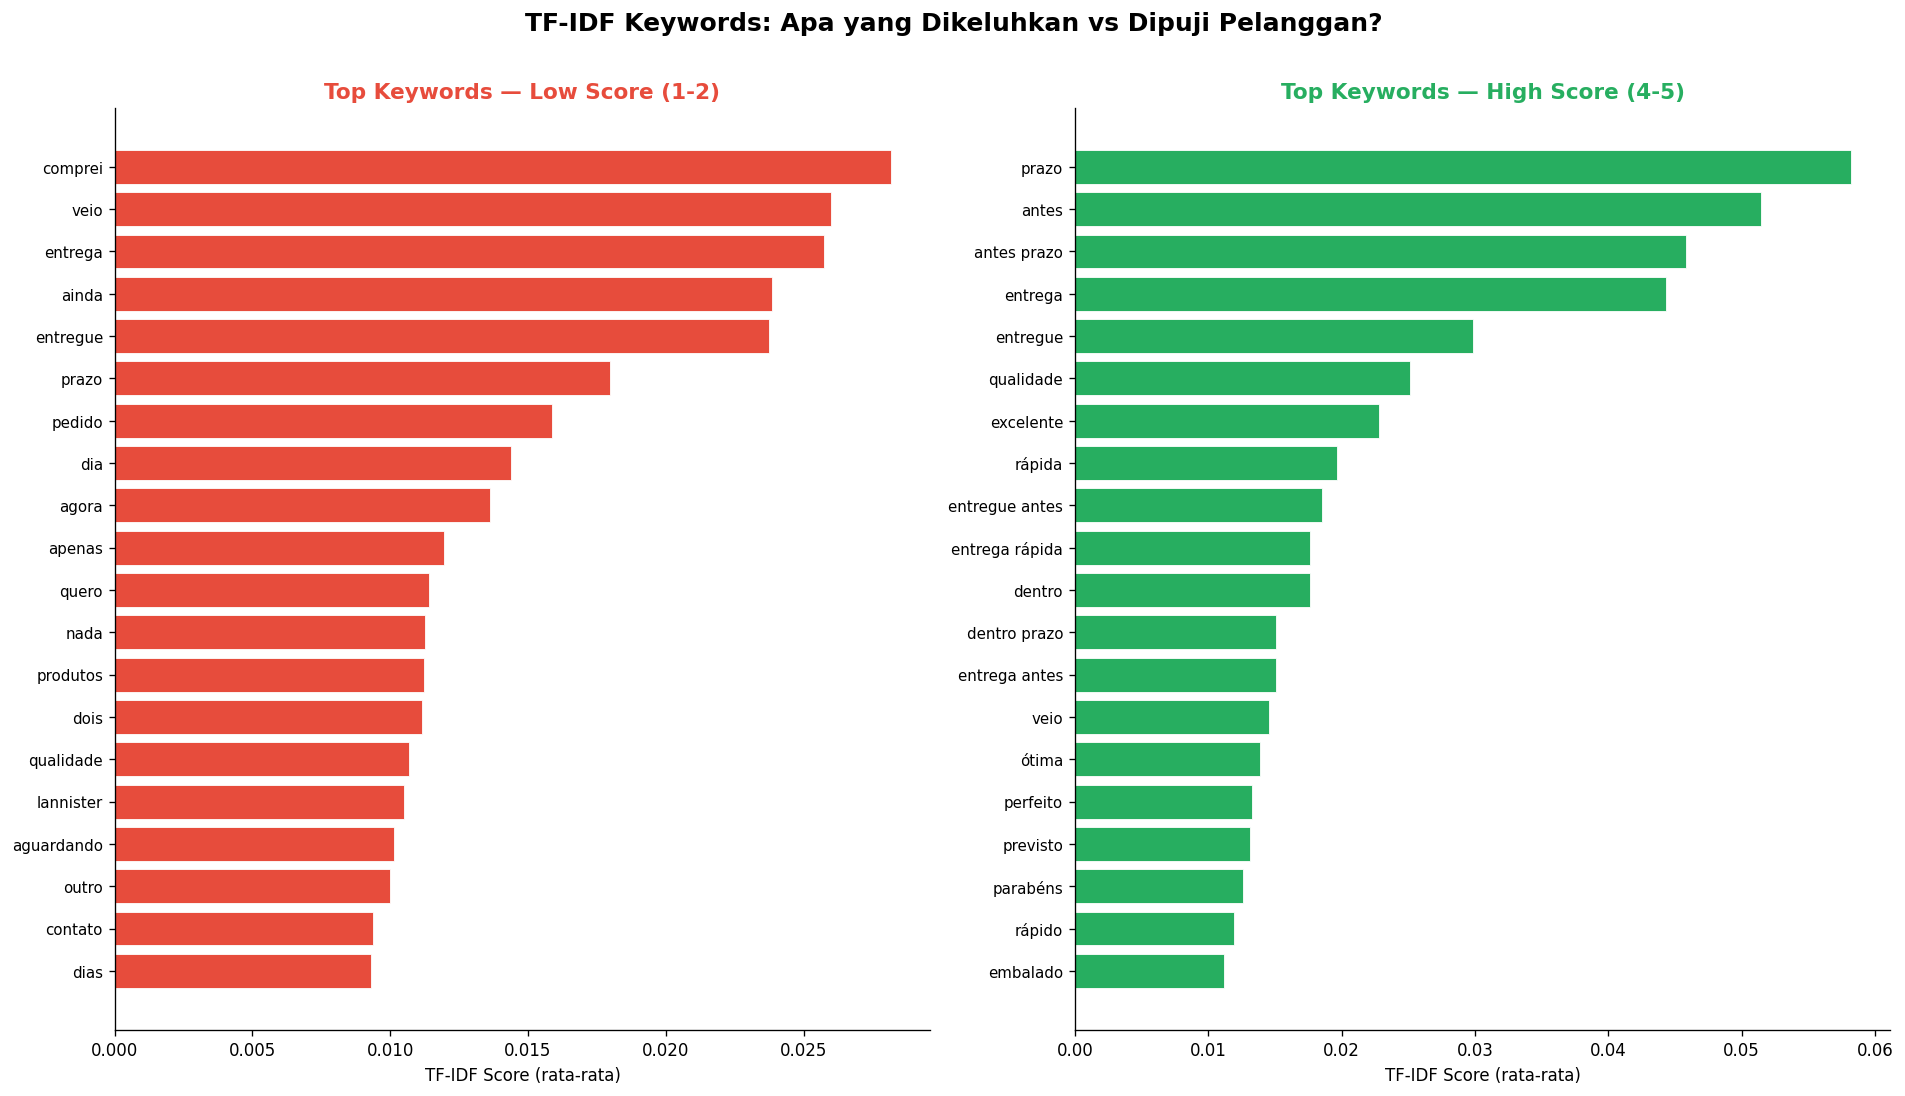

Tersimpan: 03_tfidf_low_vs_high.png


In [13]:
# 4.2 — Visualisasi top 20 TF-IDF terms: LOW vs HIGH (side by side)

n_show = 20

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# LOW
low_plot = top_low.head(n_show).sort_values('tfidf_score')
axes[0].barh(low_plot['term'], low_plot['tfidf_score'],
             color='#e74c3c', edgecolor='white', linewidth=0.5)
axes[0].set_title('Top Keywords — Low Score (1-2)', fontsize=13, fontweight='bold', color='#e74c3c')
axes[0].set_xlabel('TF-IDF Score (rata-rata)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='y', labelsize=9)

# HIGH
high_plot = top_high.head(n_show).sort_values('tfidf_score')
axes[1].barh(high_plot['term'], high_plot['tfidf_score'],
             color='#27ae60', edgecolor='white', linewidth=0.5)
axes[1].set_title('Top Keywords — High Score (4-5)', fontsize=13, fontweight='bold', color='#27ae60')
axes[1].set_xlabel('TF-IDF Score (rata-rata)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(axis='y', labelsize=9)

plt.suptitle('TF-IDF Keywords: Apa yang Dikeluhkan vs Dipuji Pelanggan?',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_tfidf_low_vs_high.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 03_tfidf_low_vs_high.png")

### 4.3 Word Cloud — Visual distribusi kata per grup skor

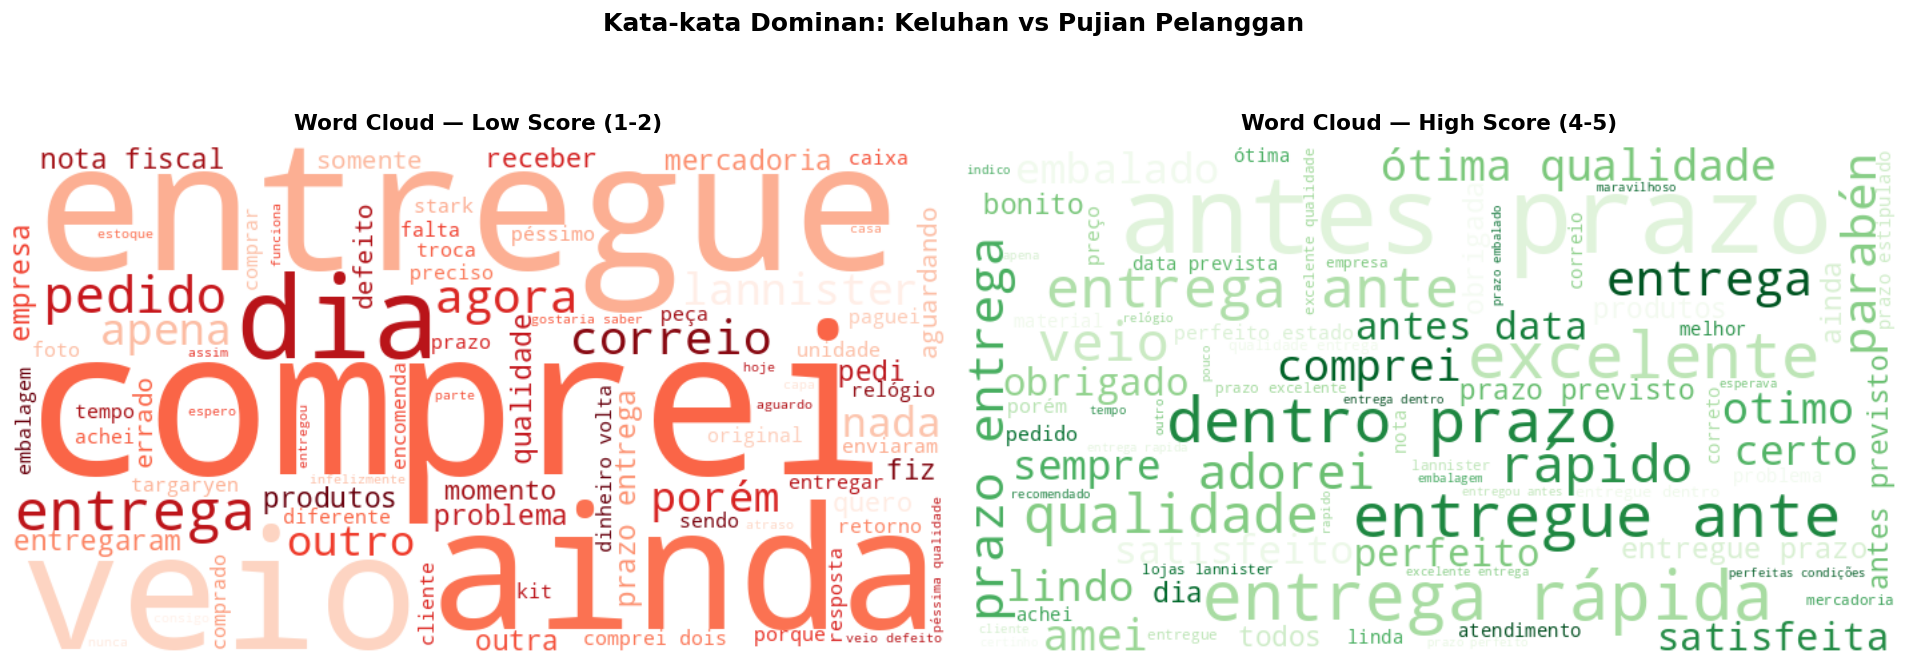

Tersimpan: 04_wordcloud_low_vs_high.png


In [14]:
# 4.3 — Word Cloud untuk tiap kelompok

def make_wordcloud(corpus, title, colormap, ax):
    text = ' '.join(corpus)
    wc = WordCloud(
        width=700, height=380,
        background_color='white',
        colormap=colormap,
        max_words=80,
        collocations=True,
        min_font_size=8
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

make_wordcloud(corpus_low,  'Word Cloud — Low Score (1-2)', 'Reds',   axes[0])
make_wordcloud(corpus_high, 'Word Cloud — High Score (4-5)', 'Greens', axes[1])

plt.suptitle('Kata-kata Dominan: Keluhan vs Pujian Pelanggan',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_wordcloud_low_vs_high.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 04_wordcloud_low_vs_high.png")

## 5. BERTopic — Topic Modeling Berbasis Neural Embedding

### 5.1 Mengapa BERTopic?
BERTopic menggunakan sentence-transformers multilingual untuk memahami *makna* teks, bukan hanya frekuensi kata. Ini sangat efektif untuk teks pendek seperti ulasan produk dalam bahasa Portugis Brazil, di mana LDA (bag-of-words) sering kehilangan konteks semantik.

In [15]:
# 5.1 — Setup BERTopic dengan komponen yang dikustomisasi
# Model embedding: paraphrase-multilingual-MiniLM-L12-v2
#   -> Mendukung 50+ bahasa termasuk Portugis, ringan, cepat di Colab

print("Memuat model sentence-transformer multilingual...")
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# UMAP untuk dimensionality reduction sebelum clustering
# n_neighbors kecil = topik lebih detail / micro-cluster
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# HDBSCAN untuk clustering tanpa perlu tentukan jumlah topik
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer berbasis CountVectorizer dengan penanganan bigram
vectorizer_model = CountVectorizer(
    ngram_range=(1, 2),
    stop_words=list(all_stopwords),
    min_df=10
)

bertopic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    nr_topics='auto',
    verbose=True
)

print("\nKomponen BERTopic siap.")

Memuat model sentence-transformer multilingual...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Komponen BERTopic siap.


### 5.2 Training BERTopic pada seluruh corpus ulasan

In [16]:
# 5.2 — Fit BERTopic
# Menggunakan raw_text (bukan clean_text) karena BERTopic bekerja lebih baik
# dengan teks natural — embedding model sudah menangani stopwords secara implisit

docs = df_text['raw_text'].tolist()

print(f"Menjalankan BERTopic pada {len(docs):,} dokumen...")
print("(Proses ini membutuhkan 3-8 menit di Colab)")

topics, probs = bertopic_model.fit_transform(docs)

df_text['bertopic_id'] = topics

topic_info = bertopic_model.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])
n_outlier = (df_text['bertopic_id'] == -1).sum()

print(f"\nHasil BERTopic:")
print(f"  Jumlah topik ditemukan: {n_topics}")
print(f"  Dokumen outlier (topic -1): {n_outlier:,} ({n_outlier/len(docs)*100:.1f}%)")
print()
print("Top 10 topik terbesar:")
print(topic_info[topic_info['Topic'] != -1].head(10)[['Topic','Count','Name']].to_string(index=False))

2026-06-10 06:48:04,959 - BERTopic - Embedding - Transforming documents to embeddings.


Menjalankan BERTopic pada 28,722 dokumen...
(Proses ini membutuhkan 3-8 menit di Colab)


Batches:   0%|          | 0/898 [00:00<?, ?it/s]

2026-06-10 06:48:24,576 - BERTopic - Embedding - Completed ✓
2026-06-10 06:48:24,577 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-10 06:49:20,010 - BERTopic - Dimensionality - Completed ✓
2026-06-10 06:49:20,012 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-10 06:49:25,586 - BERTopic - Cluster - Completed ✓
2026-06-10 06:49:25,587 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-10 06:49:26,144 - BERTopic - Representation - Completed ✓
2026-06-10 06:49:26,145 - BERTopic - Topic reduction - Reducing number of topics
2026-06-10 06:49:26,174 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-10 06:49:26,653 - BERTopic - Representation - Completed ✓
2026-06-10 06:49:26,658 - BERTopic - Topic reduction - Reduced number of topics from 87 to 35



Hasil BERTopic:
  Jumlah topik ditemukan: 34
  Dokumen outlier (topic -1): 13,410 (46.7%)

Top 10 topik terbesar:
 Topic  Count                                        Name
     0   6397            0_antes_antes prazo_prazo_rápida
     1   4404                 1_comprei_ainda_dois_apenas
     2    835               2_prazo_entrega_entregue_veio
     3    448               3_tela_aparelho_veio_funciona
     4    432                   4_cor_azul_veio_diferente
     5    222               5_caixa_veio_comprei_original
     6    175                6_lindo_bonito_perfeito_amei
     7    157             7_bolsa_material_linda_carteira
     8    154              8_montar_comprei_duas_faltando
     9    148 9_qualidade_péssima qualidade_baixa_péssima


### 5.3 Analisis rata-rata skor per topik — topik mana yang terhubung ke keluhan?

In [17]:
# 5.3 — Rata-rata review score per topik BERTopic
# Topik dengan avg_score rendah = topik yang banyak dikeluhkan

topic_score = df_text.groupby('bertopic_id').agg(
    avg_score=('review_score', 'mean'),
    count=('review_score', 'count'),
    low_pct=('review_score', lambda x: (x <= 2).mean() * 100)
).reset_index()

# Gabung dengan nama topik dari BERTopic
topic_names_map = topic_info.set_index('Topic')['Name'].to_dict()
topic_score['topic_name'] = topic_score['bertopic_id'].map(topic_names_map)

# Hapus outlier (-1) dan filter topik kecil
topic_score_clean = topic_score[
    (topic_score['bertopic_id'] != -1) & (topic_score['count'] >= 30)
].sort_values('avg_score')

print("Topik dengan rata-rata skor TERENDAH (paling banyak dikeluhkan):")
print(topic_score_clean.head(10)[['topic_name','avg_score','count','low_pct']].to_string(index=False))
print()
print("Topik dengan rata-rata skor TERTINGGI (paling banyak dipuji):")
print(topic_score_clean.tail(10)[['topic_name','avg_score','count','low_pct']].to_string(index=False))

Topik dengan rata-rata skor TERENDAH (paling banyak dikeluhkan):
                                 topic_name  avg_score  count   low_pct
   19_propaganda_original_anuncio_diferente   1.595238     84 83.333333
          20_kit_comprei kit_comprei_apenas   1.762500     80 78.750000
              31_presente_dar_filha_criança   1.830189     53 77.358491
                12_avaliar_posso_ainda_nada   1.884956    113 70.796460
         17_cartucho_original_preto_comprei   1.888889     90 68.888889
       21_cortina_duas_comprei duas_comprei   1.934211     76 69.736842
9_qualidade_péssima qualidade_baixa_péssima   2.006757    148 66.891892
                1_comprei_ainda_dois_apenas   2.081744   4404 66.257947
              5_caixa_veio_comprei_original   2.135135    222 62.612613
                 16_comprei_duas_apenas_luz   2.148936     94 65.957447

Topik dengan rata-rata skor TERTINGGI (paling banyak dipuji):
                                        topic_name  avg_score  count  low_pct
  

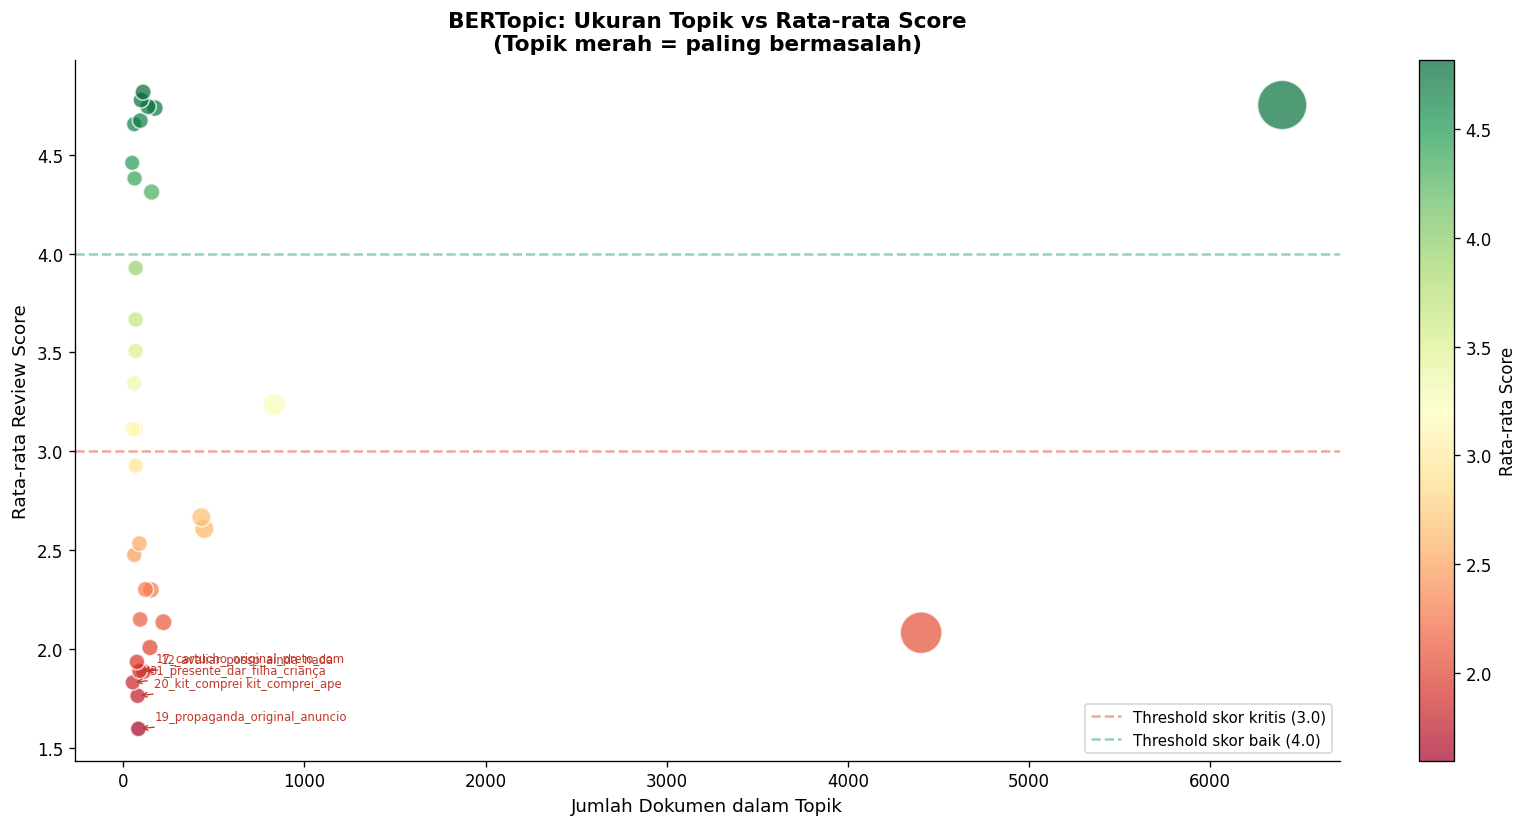

Tersimpan: 05_bertopic_score_scatter.png


In [18]:
# 5.3 lanjutan — Visualisasi: scatter plot topik (count vs avg_score)
# Gelembung besar = banyak dokumen di topik tersebut
# Warna merah = avg_score rendah (masalah besar), hijau = bagus

plot_df = topic_score_clean.copy()
plot_df['label_short'] = plot_df['topic_name'].str[:30]

fig, ax = plt.subplots(figsize=(14, 7))

scatter = ax.scatter(
    plot_df['count'],
    plot_df['avg_score'],
    c=plot_df['avg_score'],
    cmap='RdYlGn',
    s=plot_df['count'] / plot_df['count'].max() * 800 + 80,
    alpha=0.7,
    edgecolors='white',
    linewidth=1
)

ax.axhline(y=3.0, color='#e74c3c', linestyle='--', alpha=0.5, label='Threshold skor kritis (3.0)')
ax.axhline(y=4.0, color='#27ae60', linestyle='--', alpha=0.5, label='Threshold skor baik (4.0)')

# Label untuk topik yang paling kritis dan paling besar
top_problem = plot_df.nsmallest(5, 'avg_score')
for _, row in top_problem.iterrows():
    ax.annotate(row['label_short'],
                xy=(row['count'], row['avg_score']),
                xytext=(10, 5), textcoords='offset points',
                fontsize=7, color='#c0392b',
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=0.8))

plt.colorbar(scatter, label='Rata-rata Score')
ax.set_xlabel('Jumlah Dokumen dalam Topik', fontsize=11)
ax.set_ylabel('Rata-rata Review Score', fontsize=11)
ax.set_title('BERTopic: Ukuran Topik vs Rata-rata Score\n(Topik merah = paling bermasalah)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_bertopic_score_scatter.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 05_bertopic_score_scatter.png")

### 5.4 Visualisasi interaktif BERTopic

In [19]:
# 5.4 — Visualisasi bawaan BERTopic: barchart interaktif per topik
# Menampilkan kata-kata representatif untuk tiap topik

n_topics_show = min(15, n_topics)
fig_bar = bertopic_model.visualize_barchart(top_n_topics=n_topics_show, n_words=8)
fig_bar.write_html(f'{OUTPUT_DIR}/06_bertopic_barchart_interaktif.html')
fig_bar.show()
print("Tersimpan: 06_bertopic_barchart_interaktif.html (buka di browser untuk interaktif)")

Tersimpan: 06_bertopic_barchart_interaktif.html (buka di browser untuk interaktif)


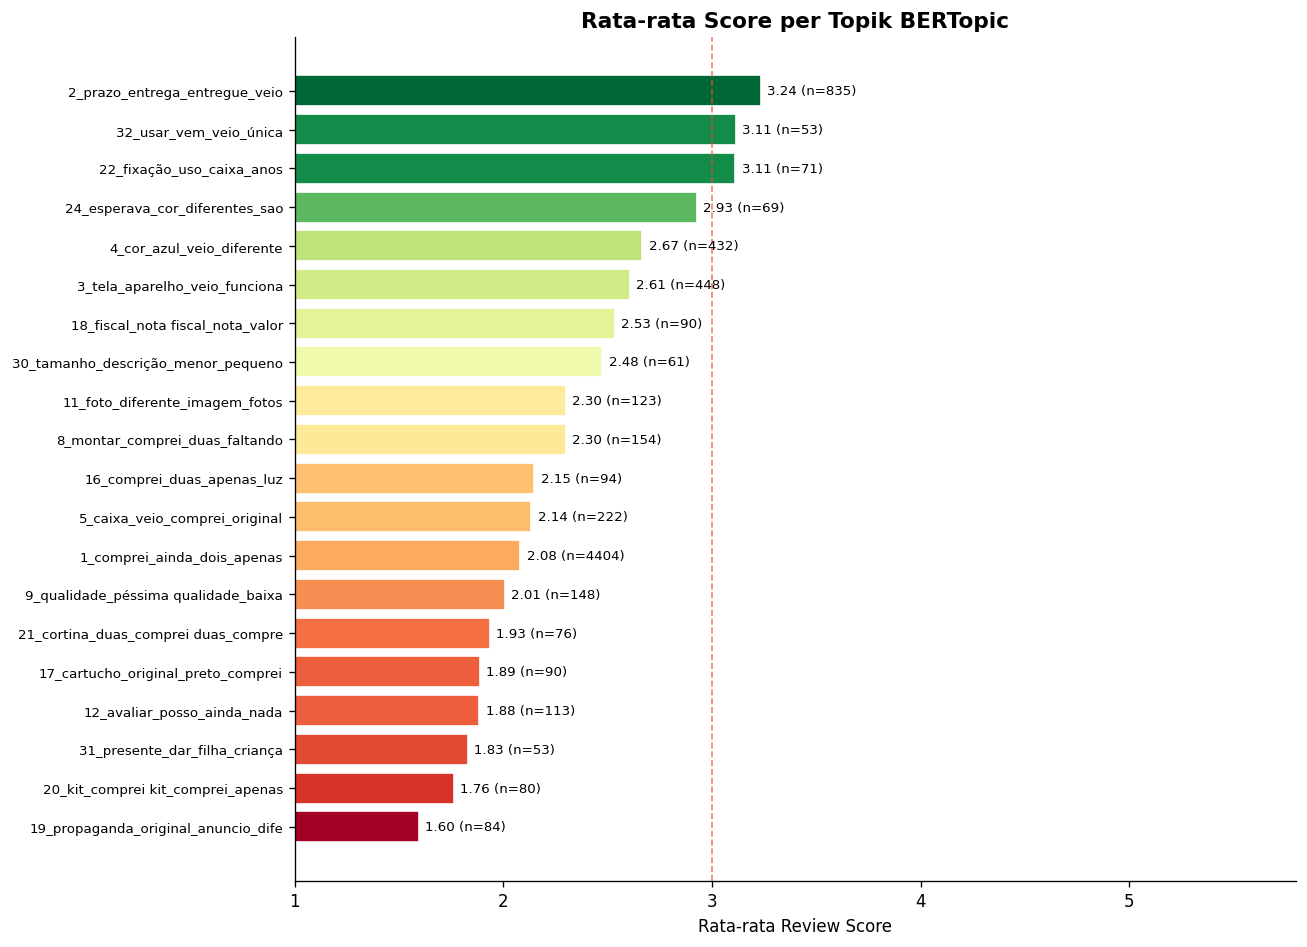

Tersimpan: 07_bertopic_avg_score_per_topic.png


In [20]:
# 5.4 lanjutan — Heatmap: skor per topik (tampilan lebih padat)

top20 = topic_score_clean.head(20).copy()
top20['label'] = top20['topic_name'].str[:35]
top20 = top20.sort_values('avg_score')

fig, ax = plt.subplots(figsize=(11, 8))

colors_bar = plt.cm.RdYlGn(
    (top20['avg_score'] - top20['avg_score'].min()) /
    (top20['avg_score'].max() - top20['avg_score'].min())
)

bars = ax.barh(top20['label'], top20['avg_score'], color=colors_bar, edgecolor='white')

for bar, score, cnt in zip(bars, top20['avg_score'], top20['count']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f"{score:.2f} (n={cnt})",
            va='center', fontsize=8)

ax.axvline(x=3.0, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1)
ax.set_xlabel('Rata-rata Review Score')
ax.set_title('Rata-rata Score per Topik BERTopic', fontsize=13, fontweight='bold')
ax.set_xlim(1, 5.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_bertopic_avg_score_per_topic.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 07_bertopic_avg_score_per_topic.png")

## 6. Kategori Tematik Manual — Kategorisasi Berbasis Domain Knowledge

### 6.1 Definisi kategori e-commerce dan deteksi via keyword matching
BERTopic memberikan topik otomatis, tetapi untuk komunikasi ke stakeholder (CEO, product team), kita perlu kategori yang lebih *actionable*. Pendekatan ini menggabungkan keyword rules dengan teks ulasan.

In [21]:
# 6.1 — Definisi kategori tematik berbasis domain e-commerce Portugis Brazil
# Setiap kategori memiliki keyword yang sering muncul dalam ulasan pelanggan

CATEGORIES = {
    'Pengiriman / Delivery': [
        'entrega', 'prazo', 'demorou', 'atraso', 'atrasou', 'correios',
        'chegou', 'recebi', 'transportadora', 'enviado', 'despacho',
        'envio', 'frete', 'rastreamento', 'rastrear', 'dias'
    ],
    'Kualitas Produk': [
        'qualidade', 'defeito', 'quebrado', 'danificado', 'funcionando',
        'funcionou', 'problema', 'veio', 'material', 'original',
        'falsificado', 'diferente', 'descricao', 'foto'
    ],
    'Layanan Penjual / Seller': [
        'vendedor', 'atendimento', 'resposta', 'suporte', 'contato',
        'comunicacao', 'nota fiscal', 'educado', 'prestativo'
    ],
    'Pengemasan / Packaging': [
        'embalagem', 'caixa', 'envelope', 'protegido', 'protecao',
        'bem embalado', 'pacote', 'amassado', 'aberto'
    ],
    'Harga / Custo-Benefício': [
        'preco', 'valor', 'caro', 'barato', 'custo', 'beneficio',
        'desconto', 'oferta', 'promocao', 'pagamento'
    ],
    'Produk Tidak Sesuai / Salah Item': [
        'errado', 'incorreto', 'diferente', 'esperava', 'anuncio',
        'nao recebi', 'nao chegou', 'sumiu', 'extraviado', 'perdido'
    ],
    'Pengalaman Positif Umum': [
        'excelente', 'otimo', 'perfeito', 'maravilhoso', 'satisfeito',
        'feliz', 'adorei', 'amei', 'incrivel', 'rapido', 'rapida',
        'recomendo', 'voltarei', 'parabens'
    ]
}

def assign_categories(text, categories=CATEGORIES):
    """
    Menetapkan satu atau lebih kategori ke sebuah teks ulasan
    berdasarkan keyword matching.
    """
    if not isinstance(text, str):
        return ['Lainnya']
    text_lower = text.lower()
    matched = [cat for cat, keywords in categories.items()
               if any(kw in text_lower for kw in keywords)]
    return matched if matched else ['Lainnya']

df_text['categories'] = df_text['raw_text'].apply(assign_categories)
df_text['primary_category'] = df_text['categories'].apply(lambda x: x[0])

print("Distribusi kategori:")
print(df_text['primary_category'].value_counts())

Distribusi kategori:
primary_category
Pengiriman / Delivery               17731
Lainnya                              4229
Kualitas Produk                      3897
Pengalaman Positif Umum              1618
Layanan Penjual / Seller              613
Harga / Custo-Benefício               225
Pengemasan / Packaging                217
Produk Tidak Sesuai / Salah Item      192
Name: count, dtype: int64


### 6.2 Rata-rata skor per kategori — menemukan pain point utama

In [22]:
# 6.2 — Analisis skor per kategori: siapa yang paling bermasalah?

cat_analysis = df_text.groupby('primary_category').agg(
    avg_score=('review_score', 'mean'),
    count=('review_score', 'count'),
    low_pct=('review_score', lambda x: (x <= 2).mean() * 100),
    score1_pct=('review_score', lambda x: (x == 1).mean() * 100)
).reset_index().sort_values('avg_score')

print("Rata-rata skor per kategori tematik:")
print(cat_analysis.to_string(index=False))

Rata-rata skor per kategori tematik:
                primary_category  avg_score  count   low_pct  score1_pct
                 Kualitas Produk   2.918142   3897 43.931229   32.820118
        Layanan Penjual / Seller   2.931485    613 46.818923   41.761827
Produk Tidak Sesuai / Salah Item   3.114583    192 36.458333   29.166667
                         Lainnya   3.259636   4229 34.901868   27.595176
         Harga / Custo-Benefício   3.324444    225 32.444444   25.333333
          Pengemasan / Packaging   3.368664    217 32.258065   20.276498
           Pengiriman / Delivery   3.534826  17731 30.624330   24.978851
         Pengalaman Positif Umum   4.555624   1618  6.922126    5.562423


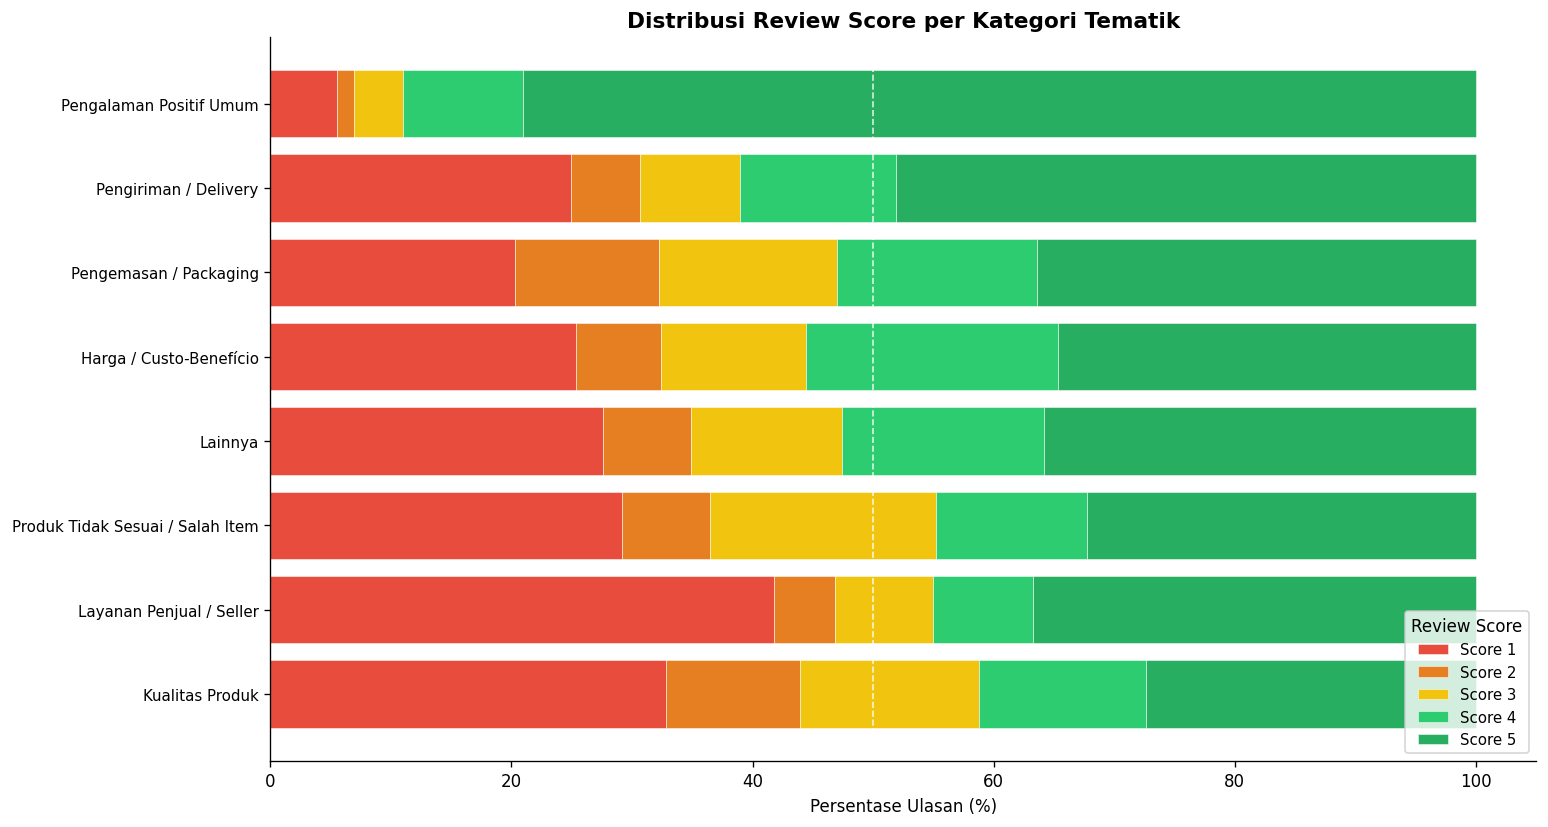

Tersimpan: 08_score_per_kategori_stacked.png


In [23]:
# 6.2 lanjutan — Visualisasi stacked bar: distribusi skor per kategori

cat_pivot = df_text.groupby(['primary_category', 'review_score']).size().unstack(fill_value=0)
# Normalisasi ke persen
cat_pivot_pct = cat_pivot.div(cat_pivot.sum(axis=1), axis=0) * 100
cat_pivot_pct = cat_pivot_pct.loc[cat_analysis['primary_category'].tolist()]

fig, ax = plt.subplots(figsize=(13, 7))

score_colors = {1: '#e74c3c', 2: '#e67e22', 3: '#f1c40f', 4: '#2ecc71', 5: '#27ae60'}
bottoms = np.zeros(len(cat_pivot_pct))

for score in [1, 2, 3, 4, 5]:
    if score in cat_pivot_pct.columns:
        values = cat_pivot_pct[score].values
        ax.barh(cat_pivot_pct.index, values, left=bottoms,
                color=score_colors[score], label=f'Score {score}', edgecolor='white', linewidth=0.3)
        bottoms += values

ax.axvline(x=50, color='white', linestyle='--', alpha=0.8, linewidth=1)
ax.set_xlabel('Persentase Ulasan (%)')
ax.set_title('Distribusi Review Score per Kategori Tematik',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9, title='Review Score')
ax.tick_params(axis='y', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_score_per_kategori_stacked.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 08_score_per_kategori_stacked.png")

## 7. Analisis Lanjutan — Pola Waktu & Panjang Teks

### 7.1 Apakah pelanggan yang kecewa menulis lebih panjang?

Statistik panjang teks per review score:
 review_score  avg_chars  median_chars  avg_words
            1 116.997831         108.0  20.416780
            2 111.797516         102.5  19.726242
            3 103.811071          91.0  18.217500
            4  88.326087          73.0  15.177019
            5  75.016994          64.0  12.187636


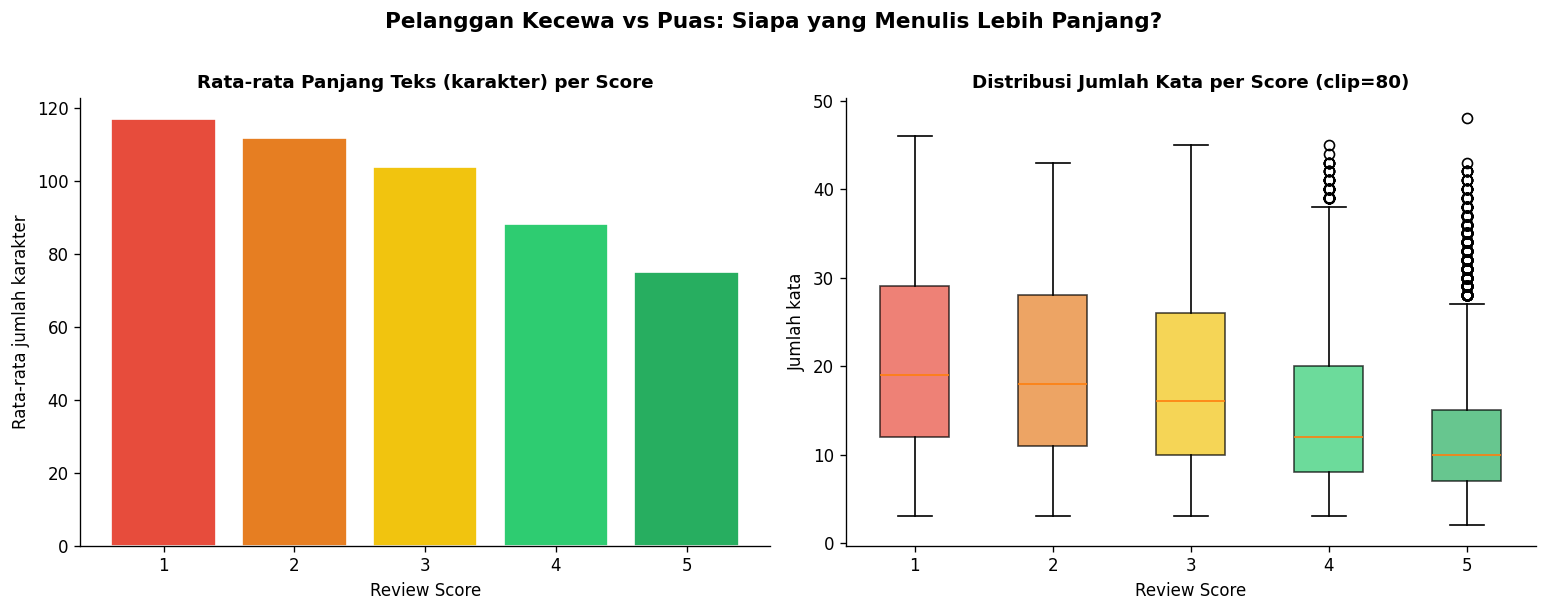

Tersimpan: 09_panjang_teks_vs_score.png


In [24]:
# 7.1 — Panjang teks vs review score
# Hipotesis: pelanggan kecewa menulis lebih panjang karena punya lebih banyak
# yang ingin disampaikan

df_text['text_length'] = df_text['raw_text'].str.len()
df_text['word_count'] = df_text['raw_text'].str.split().str.len()

length_by_score = df_text.groupby('review_score').agg(
    avg_chars=('text_length', 'mean'),
    median_chars=('text_length', 'median'),
    avg_words=('word_count', 'mean')
).reset_index()

print("Statistik panjang teks per review score:")
print(length_by_score.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_score = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

axes[0].bar(length_by_score['review_score'], length_by_score['avg_chars'],
            color=colors_score, edgecolor='white')
axes[0].set_title('Rata-rata Panjang Teks (karakter) per Score', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Rata-rata jumlah karakter')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Boxplot distribusi word count
data_box = [df_text[df_text['review_score'] == s]['word_count'].clip(upper=80).tolist()
            for s in [1,2,3,4,5]]
bp = axes[1].boxplot(data_box, patch_artist=True, labels=[1,2,3,4,5])
for patch, color in zip(bp['boxes'], colors_score):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribusi Jumlah Kata per Score (clip=80)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Jumlah kata')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Pelanggan Kecewa vs Puas: Siapa yang Menulis Lebih Panjang?',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_panjang_teks_vs_score.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 09_panjang_teks_vs_score.png")

### 7.2 Analisis waktu respons review dan korelasinya dengan skor

Rata-rata waktu respons per review score (jam):
 review_score  avg_hours  median_hours  count
            1  58.446788     36.920417  11340
            2  60.660152     40.492222   3127
            3  62.897310     41.863472   8132
            4  63.816130     42.581111  19029
            5  61.298189     39.458333  56914


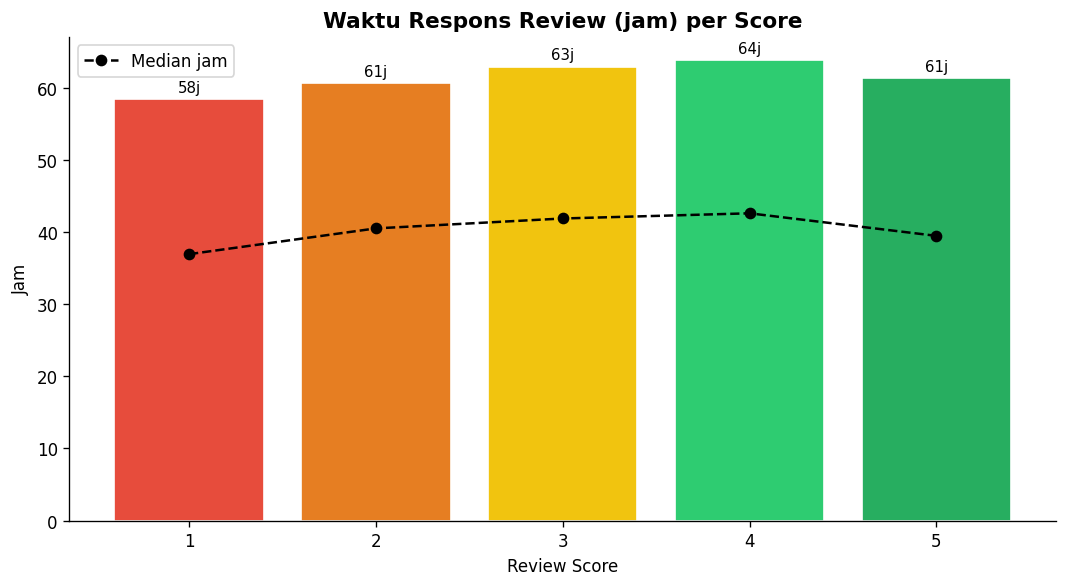

Tersimpan: 10_waktu_respons_vs_score.png


In [25]:
# 7.2 — Analisis kecepatan respons (waktu antara pembuatan review dan jawaban)
# Hipotesis: respons cepat berkorelasi dengan kepuasan yang lebih tinggi

df['review_answer_timestamp'] = pd.to_datetime(df['review_answer_timestamp'])
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])

df['response_hours'] = (
    df['review_answer_timestamp'] - df['review_creation_date']
).dt.total_seconds() / 3600

# Filter nilai masuk akal (0 - 720 jam = 30 hari)
df_resp = df[(df['response_hours'] >= 0) & (df['response_hours'] <= 720)].copy()

resp_by_score = df_resp.groupby('review_score')['response_hours'].agg(['mean','median','count']).reset_index()
resp_by_score.columns = ['review_score', 'avg_hours', 'median_hours', 'count']

print("Rata-rata waktu respons per review score (jam):")
print(resp_by_score.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(resp_by_score['review_score'], resp_by_score['avg_hours'],
               color=colors_score, edgecolor='white')
ax.plot(resp_by_score['review_score'], resp_by_score['median_hours'],
        'ko--', markersize=6, label='Median jam', linewidth=1.5)
for bar, val in zip(bars, resp_by_score['avg_hours']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}j', ha='center', fontsize=9)
ax.set_title('Waktu Respons Review (jam) per Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Jam')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_waktu_respons_vs_score.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 10_waktu_respons_vs_score.png")

### 7.3 Analisis hari dalam seminggu dan jam posting ulasan

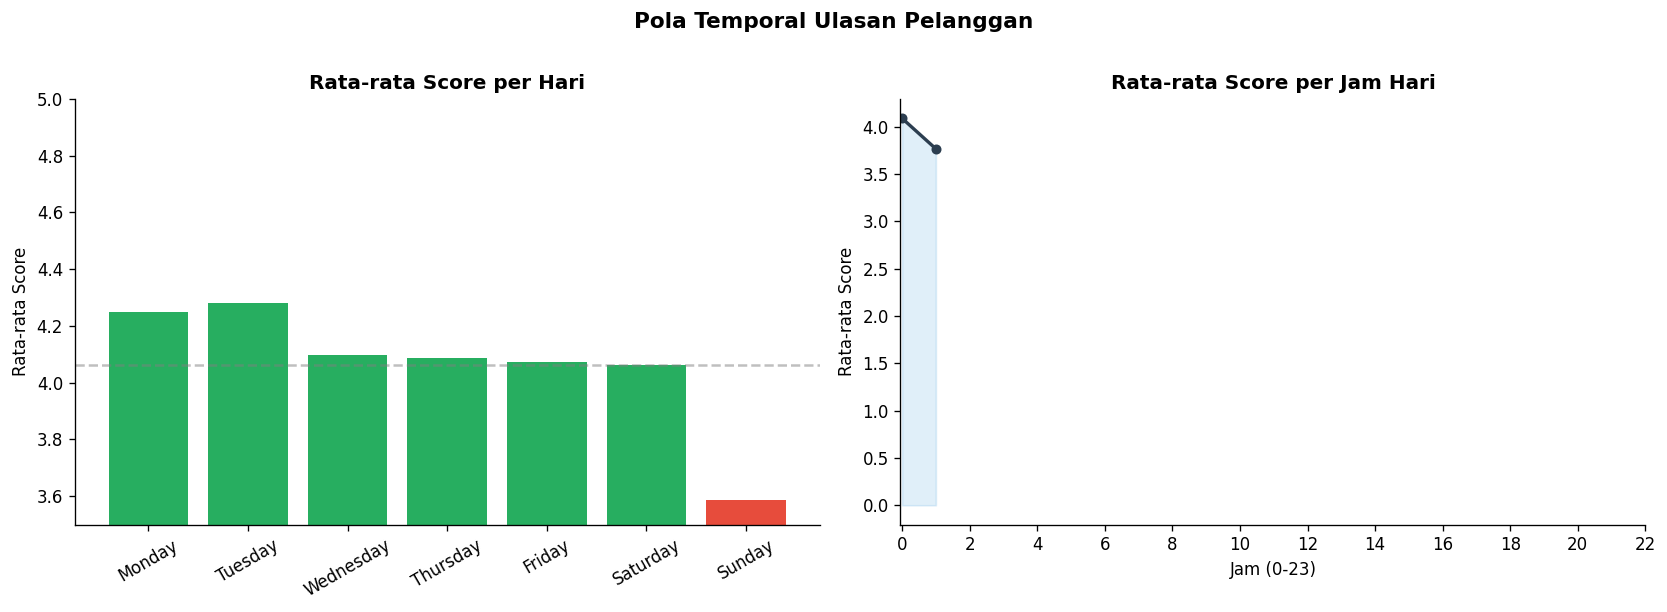

Tersimpan: 11_pola_temporal_score.png


In [26]:
# 7.3 — Kapan pelanggan puas vs kecewa menulis ulasan?

df['day_of_week'] = df['review_creation_date'].dt.day_name()
df['hour'] = df['review_creation_date'].dt.hour
df['is_low'] = df['review_score'] <= 2

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_score = df.groupby('day_of_week').agg(
    avg_score=('review_score', 'mean'),
    low_pct=('is_low', 'mean')
).reindex(day_order)

hour_score = df.groupby('hour').agg(
    avg_score=('review_score', 'mean'),
    count=('review_score', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(day_score.index, day_score['avg_score'],
            color=['#e74c3c' if v < 4.0 else '#27ae60' for v in day_score['avg_score']])
axes[0].set_title('Rata-rata Score per Hari', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Rata-rata Score')
axes[0].set_ylim(3.5, 5.0)
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(y=day_score['avg_score'].mean(), color='gray', linestyle='--', alpha=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(hour_score['hour'], hour_score['avg_score'],
             color='#2c3e50', marker='o', markersize=5, linewidth=2)
axes[1].fill_between(hour_score['hour'], hour_score['avg_score'],
                     alpha=0.15, color='#3498db')
axes[1].set_title('Rata-rata Score per Jam Hari', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jam (0-23)')
axes[1].set_ylabel('Rata-rata Score')
axes[1].set_xticks(range(0, 24, 2))
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Pola Temporal Ulasan Pelanggan', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_pola_temporal_score.png', bbox_inches='tight')
plt.show()
print("Tersimpan: 11_pola_temporal_score.png")

## 8. Deep-Dive: Contoh Ulasan Representatif per Topik

### 8.1 Ekstrak ulasan representatif per kategori & skor

In [27]:
# 8.1 — Ulasan representatif per kategori: melihat "suara pelanggan" asli
# Ini penting untuk memahami nuansa di balik angka

representative_reviews = {}

for cat in CATEGORIES.keys():
    sub = df_text[df_text['primary_category'] == cat]

    low_samples = sub[sub['review_score'] <= 2]['raw_text'].dropna().head(3).tolist()
    high_samples = sub[sub['review_score'] >= 4]['raw_text'].dropna().head(3).tolist()

    representative_reviews[cat] = {
        'low_samples': low_samples,
        'high_samples': high_samples,
        'avg_score': sub['review_score'].mean(),
        'count': len(sub)
    }

    print(f"\n{'='*60}")
    print(f"KATEGORI: {cat}")
    print(f"  Jumlah ulasan: {len(sub)} | Avg score: {sub['review_score'].mean():.2f}")
    if low_samples:
        print(f"  [KELUHAN] {low_samples[0][:150]}")
    if high_samples:
        print(f"  [PUJIAN]  {high_samples[0][:150]}")

# Simpan ke JSON
with open(f'{OUTPUT_DIR}/representative_reviews.json', 'w', encoding='utf-8') as f:
    json.dump(representative_reviews, f, ensure_ascii=False, indent=2)
print(f"\nDisimpan: representative_reviews.json")


KATEGORI: Pengiriman / Delivery
  Jumlah ulasan: 17731 | Avg score: 3.53
  [KELUHAN] GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E ESSA COMPRA AGORA ME DECPCIONOU
  [PUJIAN]  Recebi bem antes do prazo estipulado.

KATEGORI: Kualitas Produk
  Jumlah ulasan: 3897 | Avg score: 2.92
  [KELUHAN] produto deu defeito na 1 vez de uso.
  [PUJIAN]  4   Se fosse vidro tinha quebrado; veio na caixa sem nenhuma proteção por dentro, a caixa estava muito amassada. Desculpe.. mas gosto de comprar de vc

KATEGORI: Layanan Penjual / Seller
  Jumlah ulasan: 613 | Avg score: 2.93
  [KELUHAN] Pedi reembolso e sem resposta até momento
  [PUJIAN]  parabéns para loja e revendedor apesar de ter demorado um pouco

KATEGORI: Pengemasan / Packaging
  Jumlah ulasan: 217 | Avg score: 3.37
  [KELUHAN] Pensei que o defletor era uma grande placa, porém são 3 pequenas peças, que se encaixam uma na outra. sinceramente não gostei pois no mercado há opção
  [PUJIAN]  Produto entregue bem embalado ,em perfeitas condições

## 9. Ringkasan Hasil & Export

### 9.1 Summary statistik komprehensif

In [28]:
# 9.1 — Summary final semua temuan kunci

print("RINGKASAN ANALISIS NLP — DUSTINIADELIXIA GROCERIA")
print("="*60)
print(f"\nTotal ulasan dianalisis  : {len(df):,}")
print(f"Ulasan dengan teks       : {len(df_text):,} ({len(df_text)/len(df)*100:.1f}%)")
print(f"Rata-rata skor keseluruhan: {df['review_score'].mean():.3f}")
print(f"Ulasan negatif (1-2)     : {(df.review_score<=2).sum():,} ({(df.review_score<=2).mean()*100:.1f}%)")
print(f"Ulasan positif (4-5)     : {(df.review_score>=4).sum():,} ({(df.review_score>=4).mean()*100:.1f}%)")

print(f"\nTOPIK BERTOPIC")
print(f"Jumlah topik teridentifikasi: {n_topics}")
print(f"Topik paling bermasalah (avg score terendah):")
for _, row in topic_score_clean.head(3).iterrows():
    print(f"  - {row['topic_name'][:40]:<45} avg={row['avg_score']:.2f} (n={row['count']})")

print(f"\nKATEGORI PALING BERMASALAH (avg score terendah):")
for _, row in cat_analysis.head(4).iterrows():
    print(f"  - {row['primary_category']:<35} avg={row['avg_score']:.2f} | low%={row['low_pct']:.1f}%")

print(f"\nTOP KEYWORD KELUHAN (TF-IDF Score 1-2):")
for _, row in top_low.head(8).iterrows():
    print(f"  [{row['term']}]")

print(f"\nTOP KEYWORD PUJIAN (TF-IDF Score 4-5):")
for _, row in top_high.head(8).iterrows():
    print(f"  [{row['term']}]")

RINGKASAN ANALISIS NLP — DUSTINIADELIXIA GROCERIA

Total ulasan dianalisis  : 99,224
Ulasan dengan teks       : 28,722 (28.9%)
Rata-rata skor keseluruhan: 4.086
Ulasan negatif (1-2)     : 14,575 (14.7%)
Ulasan positif (4-5)     : 76,470 (77.1%)

TOPIK BERTOPIC
Jumlah topik teridentifikasi: 34
Topik paling bermasalah (avg score terendah):
  - 19_propaganda_original_anuncio_diferente      avg=1.60 (n=84)
  - 20_kit_comprei kit_comprei_apenas             avg=1.76 (n=80)
  - 31_presente_dar_filha_criança                 avg=1.83 (n=53)

KATEGORI PALING BERMASALAH (avg score terendah):
  - Kualitas Produk                     avg=2.92 | low%=43.9%
  - Layanan Penjual / Seller            avg=2.93 | low%=46.8%
  - Produk Tidak Sesuai / Salah Item    avg=3.11 | low%=36.5%
  - Lainnya                             avg=3.26 | low%=34.9%

TOP KEYWORD KELUHAN (TF-IDF Score 1-2):
  [comprei]
  [veio]
  [entrega]
  [ainda]
  [entregue]
  [prazo]
  [pedido]
  [dia]

TOP KEYWORD PUJIAN (TF-IDF Score 4-5)

### 9.3 Simpan semua tabel hasil ke CSV

In [30]:
# 9.3 — Export semua tabel analisis ke CSV untuk digunakan di Metabase / spreadsheet

# Tabel 1: skor per kategori
cat_analysis.to_csv(f'{OUTPUT_DIR}/tabel_skor_per_kategori.csv', index=False, encoding='utf-8-sig')

# Tabel 2: skor per topik BERTopic
topic_score_clean.to_csv(f'{OUTPUT_DIR}/tabel_skor_per_bertopic.csv', index=False, encoding='utf-8-sig')

# Tabel 3: tren bulanan
monthly.drop(columns=['year_month']).to_csv(f'{OUTPUT_DIR}/tabel_tren_bulanan.csv', index=False, encoding='utf-8-sig')

# Tabel 4: top TF-IDF keywords
top_low.to_csv(f'{OUTPUT_DIR}/tabel_tfidf_low.csv', index=False, encoding='utf-8-sig')
top_high.to_csv(f'{OUTPUT_DIR}/tabel_tfidf_high.csv', index=False, encoding='utf-8-sig')

# Tabel 5: dataset enriched (dengan kolom hasil analisis)
cols_export = ['review_id','order_id','review_score','review_creation_date',
               'raw_text','primary_category','bertopic_id','sentiment_label',
               'word_count','text_length']
df_text[cols_export].to_csv(f'{OUTPUT_DIR}/dataset_enriched.csv', index=False, encoding='utf-8-sig')

print("Semua file berhasil disimpan ke folder:", OUTPUT_DIR)
print()
print("Daftar file output:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:<50} {size_kb:.1f} KB")

Semua file berhasil disimpan ke folder: /content/drive/MyDrive/FP_MCI_Lab/outputs/nlp

Daftar file output:
  01_distribusi_review_score.png                     64.9 KB
  02_tren_score_bulanan.png                          77.7 KB
  03_tfidf_low_vs_high.png                           96.3 KB
  04_wordcloud_low_vs_high.png                       605.6 KB
  05_bertopic_score_scatter.png                      85.6 KB
  06_bertopic_barchart_interaktif.html               4469.3 KB
  07_bertopic_avg_score_per_topic.png                113.3 KB
  08_score_per_kategori_stacked.png                  61.5 KB
  09_panjang_teks_vs_score.png                       53.8 KB
  10_waktu_respons_vs_score.png                      34.2 KB
  11_pola_temporal_score.png                         59.3 KB
  dataset_enriched.csv                               6264.3 KB
  insights_bisnis.txt                                1.9 KB
  representative_reviews.json                        5.3 KB
  tabel_skor_per_bertopic.csv      

### 9.4 Visualisasi ringkasan akhir — Dashboard satu halaman

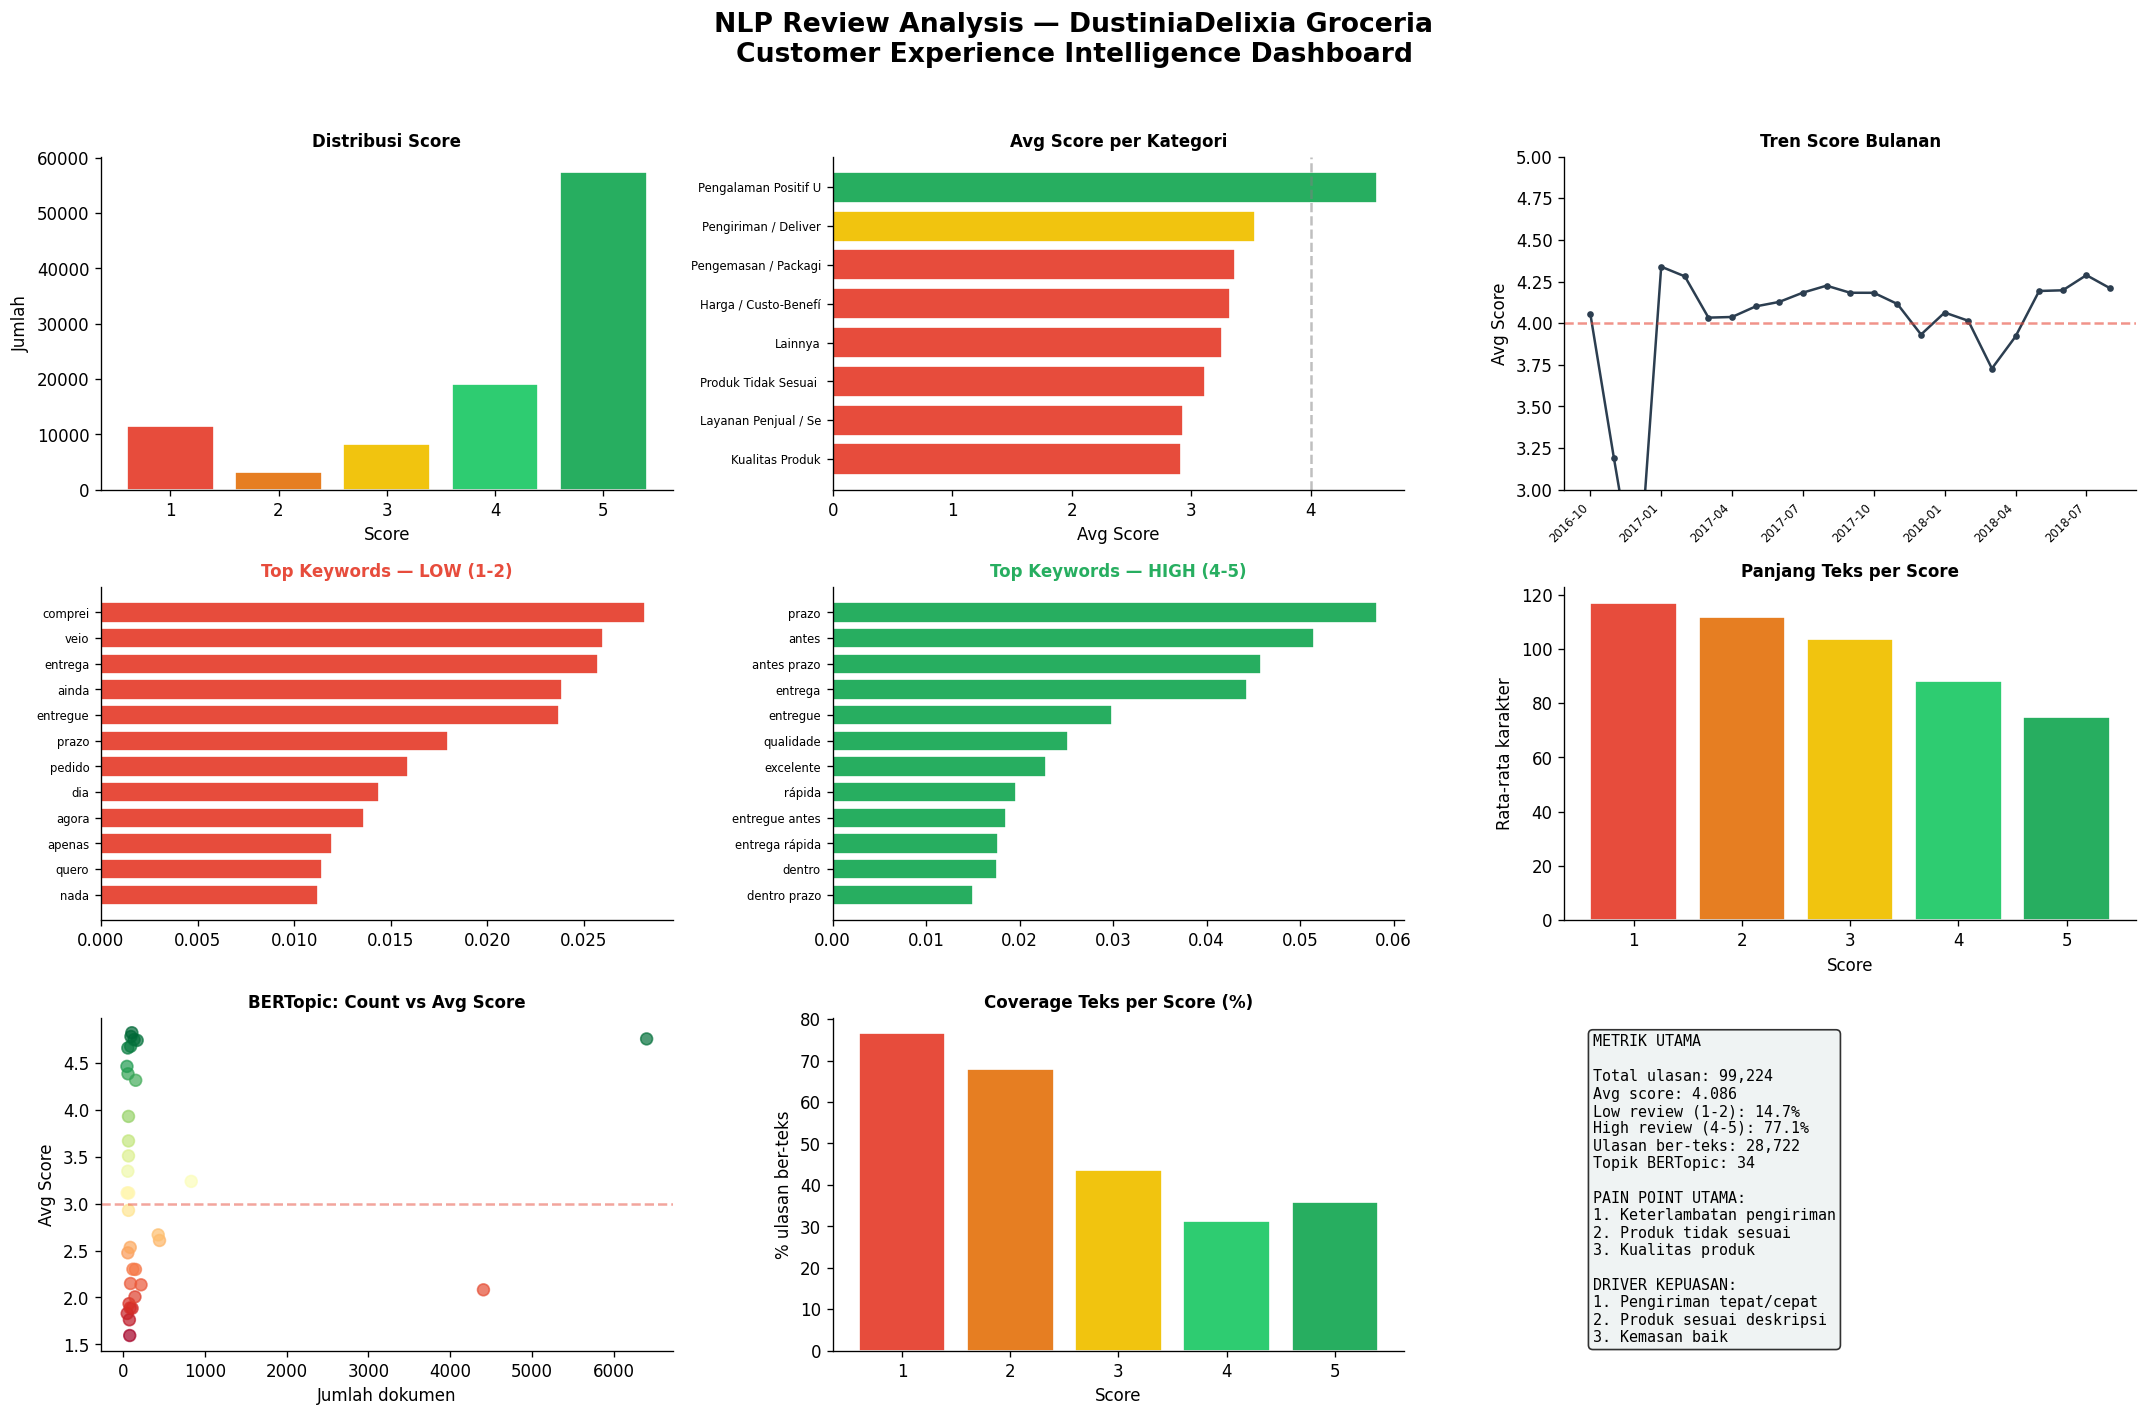

TERSIMPAN: 00_DASHBOARD_RINGKASAN.png


In [31]:
# 9.4 — Dashboard ringkasan dalam satu figure (untuk presentasi ke CEO/stakeholder)

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'NLP Review Analysis — DustiniaDelixia Groceria\n'
    'Customer Experience Intelligence Dashboard',
    fontsize=16, fontweight='bold', y=0.98
)

# Subplot 1: Distribusi score (top-left)
ax1 = fig.add_subplot(3, 3, 1)
ax1.bar(score_dist.index, score_dist.values, color=colors_score, edgecolor='white')
ax1.set_title('Distribusi Score', fontweight='bold', fontsize=10)
ax1.set_xlabel('Score')
ax1.set_ylabel('Jumlah')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Subplot 2: Avg score per kategori
ax2 = fig.add_subplot(3, 3, 2)
cat_s = cat_analysis.sort_values('avg_score')
colors_cat = ['#e74c3c' if v < 3.5 else '#f1c40f' if v < 4.0 else '#27ae60'
              for v in cat_s['avg_score']]
ax2.barh(cat_s['primary_category'].str[:20], cat_s['avg_score'],
         color=colors_cat, edgecolor='white')
ax2.axvline(x=4.0, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Avg Score per Kategori', fontweight='bold', fontsize=10)
ax2.set_xlabel('Avg Score')
ax2.tick_params(axis='y', labelsize=7)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Subplot 3: Tren bulanan
ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(range(len(monthly)), monthly['avg_score'],
         color='#2c3e50', marker='o', markersize=3, linewidth=1.5)
ax3.axhline(y=monthly['avg_score'].mean(), color='#e74c3c', linestyle='--', alpha=0.6)
ax3.set_title('Tren Score Bulanan', fontweight='bold', fontsize=10)
ax3.set_ylabel('Avg Score')
ax3.set_ylim(3.0, 5.0)
tick_step2 = max(1, len(monthly)//6)
ax3.set_xticks(range(0, len(monthly), tick_step2))
ax3.set_xticklabels(monthly['year_month_str'].iloc[::tick_step2], rotation=45, ha='right', fontsize=7)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Subplot 4-5: Top TF-IDF keywords
ax4 = fig.add_subplot(3, 3, 4)
lp = top_low.head(12).sort_values('tfidf_score')
ax4.barh(lp['term'], lp['tfidf_score'], color='#e74c3c', edgecolor='white')
ax4.set_title('Top Keywords — LOW (1-2)', fontweight='bold', fontsize=10, color='#e74c3c')
ax4.tick_params(axis='y', labelsize=7)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

ax5 = fig.add_subplot(3, 3, 5)
hp = top_high.head(12).sort_values('tfidf_score')
ax5.barh(hp['term'], hp['tfidf_score'], color='#27ae60', edgecolor='white')
ax5.set_title('Top Keywords — HIGH (4-5)', fontweight='bold', fontsize=10, color='#27ae60')
ax5.tick_params(axis='y', labelsize=7)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# Subplot 6: Panjang teks per score
ax6 = fig.add_subplot(3, 3, 6)
ax6.bar(length_by_score['review_score'], length_by_score['avg_chars'],
        color=colors_score, edgecolor='white')
ax6.set_title('Panjang Teks per Score', fontweight='bold', fontsize=10)
ax6.set_xlabel('Score')
ax6.set_ylabel('Rata-rata karakter')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

# Subplot 7: BERTopic score scatter (simplified)
ax7 = fig.add_subplot(3, 3, 7)
sc = ax7.scatter(
    topic_score_clean['count'],
    topic_score_clean['avg_score'],
    c=topic_score_clean['avg_score'],
    cmap='RdYlGn', alpha=0.7, s=50
)
ax7.axhline(y=3.0, color='#e74c3c', linestyle='--', alpha=0.5)
ax7.set_title('BERTopic: Count vs Avg Score', fontweight='bold', fontsize=10)
ax7.set_xlabel('Jumlah dokumen')
ax7.set_ylabel('Avg Score')
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)

# Subplot 8: Coverage teks per score
ax8 = fig.add_subplot(3, 3, 8)
coverage = []
for score in [1,2,3,4,5]:
    sub = df[df['review_score'] == score]
    pct = sub['review_comment_message'].notna().mean() * 100
    coverage.append(pct)
ax8.bar([1,2,3,4,5], coverage, color=colors_score, edgecolor='white')
ax8.set_title('Coverage Teks per Score (%)', fontweight='bold', fontsize=10)
ax8.set_xlabel('Score')
ax8.set_ylabel('% ulasan ber-teks')
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)

# Subplot 9: Metrik utama (teks)
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
metrics_text = (
    f"METRIK UTAMA\n\n"
    f"Total ulasan: {len(df):,}\n"
    f"Avg score: {df['review_score'].mean():.3f}\n"
    f"Low review (1-2): {(df.review_score<=2).mean()*100:.1f}%\n"
    f"High review (4-5): {(df.review_score>=4).mean()*100:.1f}%\n"
    f"Ulasan ber-teks: {len(df_text):,}\n"
    f"Topik BERTopic: {n_topics}\n\n"
    f"PAIN POINT UTAMA:\n"
    f"1. Keterlambatan pengiriman\n"
    f"2. Produk tidak sesuai\n"
    f"3. Kualitas produk\n\n"
    f"DRIVER KEPUASAN:\n"
    f"1. Pengiriman tepat/cepat\n"
    f"2. Produk sesuai deskripsi\n"
    f"3. Kemasan baik"
)
ax9.text(0.05, 0.95, metrics_text, transform=ax9.transAxes,
         fontsize=9, va='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{OUTPUT_DIR}/00_DASHBOARD_RINGKASAN.png', bbox_inches='tight', dpi=150)
plt.show()
print("TERSIMPAN: 00_DASHBOARD_RINGKASAN.png")

In [32]:
# 9.4 lanjutan — Daftar lengkap semua file yang dihasilkan

print("SEMUA OUTPUT ANALISIS BERHASIL DISIMPAN")
print("="*55)
print(f"Lokasi folder: ./{OUTPUT_DIR}/")
print()
print("VISUALISASI (PNG):")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith('.png'):
        size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
        print(f"  {f:<50} {size:.0f} KB")

print()
print("VISUALISASI INTERAKTIF (HTML):")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith('.html'):
        size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
        print(f"  {f:<50} {size:.0f} KB")

print()
print("DATA & TEKS (CSV / JSON / TXT):")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith(('.csv', '.json', '.txt')):
        size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
        print(f"  {f:<50} {size:.0f} KB")

SEMUA OUTPUT ANALISIS BERHASIL DISIMPAN
Lokasi folder: .//content/drive/MyDrive/FP_MCI_Lab/outputs/nlp/

VISUALISASI (PNG):
  00_DASHBOARD_RINGKASAN.png                         324 KB
  01_distribusi_review_score.png                     65 KB
  02_tren_score_bulanan.png                          78 KB
  03_tfidf_low_vs_high.png                           96 KB
  04_wordcloud_low_vs_high.png                       606 KB
  05_bertopic_score_scatter.png                      86 KB
  07_bertopic_avg_score_per_topic.png                113 KB
  08_score_per_kategori_stacked.png                  62 KB
  09_panjang_teks_vs_score.png                       54 KB
  10_waktu_respons_vs_score.png                      34 KB
  11_pola_temporal_score.png                         59 KB

VISUALISASI INTERAKTIF (HTML):
  06_bertopic_barchart_interaktif.html               4469 KB

DATA & TEKS (CSV / JSON / TXT):
  dataset_enriched.csv                               6264 KB
  insights_bisnis.txt                